# Random Forest sanity check (metadata + per-lead mean/std)

- Train on folds 0–3, evaluate on fold 4
- **bp** preprocessing
- Features: age, sex, per-lead mean + std (12 leads)
- Center-crop to 2500 samples (match DL input length)


In [2]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

# ---- Config ----
META_PATH = Path(os.environ.get("META_PATH", "/home/flo178/projects/master-thesis/datasets/physionet2025/processedMaster/metadata.csv"))
PREPROCS = ["bp", "bp_sc", "bp_sc_norm"]
CROP_SIZE = 2500

SEED = 42
N_ESTIMATORS = 500
N_JOBS = -1

torch.manual_seed(SEED)
np.random.seed(SEED)


/home/flo178/projects/master-thesis/ecg-chagas-embeddings/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
meta = pd.read_csv(META_PATH, low_memory=False)
if "processed_root" not in meta.columns:
    meta["processed_root"] = str(META_PATH.parent)

# Drop rows without labels
meta = meta[~meta["chagas"].isna()].copy()


print("Meta rows:", len(meta))


Meta rows: 366185


In [4]:
def _center_crop_or_pad(ecg: torch.Tensor, target_len: int) -> torch.Tensor:
    n = ecg.shape[-1]
    if n == target_len:
        return ecg
    if n < target_len:
        pad = target_len - n
        left = pad // 2
        right = pad - left
        return F.pad(ecg, (left, right))
    start = (n - target_len) // 2
    return ecg[:, start : start + target_len]

def load_ecg(path: str) -> torch.Tensor:
    ecg = torch.load(path, map_location="cpu")
    if isinstance(ecg, dict):
        for k in ("ecg", "signal", "x"):
            if k in ecg:
                ecg = ecg[k]
                break
    if hasattr(ecg, "ndim") and ecg.ndim == 3:
        ecg = ecg[0]
    if ecg.shape[0] != 12:
        raise ValueError(f"Expected ECG shape [12, T], got {tuple(ecg.shape)} for {path}")
    ecg = ecg.to(torch.float32)
    ecg = _center_crop_or_pad(ecg, CROP_SIZE)
    return ecg

def extract_features(row):
    path = row["pt_path"]
    if not Path(path).is_file():
        return None
    ecg = load_ecg(path)
    means = ecg.mean(dim=1)
    stds = ecg.std(dim=1, unbiased=False)

    feat = {
        "exam_id": row["exam_id"],
        "fold": row["fold"],
        "chagas": row["chagas"],
        "age": pd.to_numeric(row.get("age", np.nan), errors="coerce"),
    }

    sex = row.get("sex", np.nan)
    if isinstance(sex, str):
        sex = sex.strip().lower()
        if sex in ("male", "m"):
            feat["sex_male"] = 1.0
        elif sex in ("female", "f"):
            feat["sex_male"] = 0.0
        else:
            feat["sex_male"] = np.nan
    else:
        feat["sex_male"] = np.nan

    for i in range(12):
        feat[f"ch{i:02d}_mean"] = float(means[i])
        feat[f"ch{i:02d}_std"] = float(stds[i])
    return feat


In [5]:
# RF helpers (mean/std only)
import sys
from pathlib import Path as _Path

_cwd = _Path().resolve()
if _cwd.name == 'notebooks':
    _repo_root = _cwd.parent.parent.parent
else:
    _repo_root = _cwd
for _p in (str(_repo_root), str(_repo_root / 'src')):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from ecg_chagas_embeddings.helper_code import compute_challenge_score
from ecg_chagas_embeddings.analysis.embeddings_probe import (
    compute_tpr_at_top_fraction,
    compute_binary_pauc,
)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

def _resolve_stem(row):
    """
    Determine a sensible file stem for a metadata row.
    Tries common identifier columns and falls back to the row index.
    """
    for key in ("stem", "pt_id", "patient_id", "uid", "file", "filename", "name"):
        if key in row and pd.notna(row.get(key)):
            return str(row.get(key))
    if "id" in row and pd.notna(row.get("id")):
        return str(row.get("id"))
    try:
        return str(row.name)
    except Exception:
        # Last resort: create a stable hash from the row values
        return str(abs(hash(tuple(row.values))) )
    
def extract_features_for_preproc(preproc: str):
    data_root = Path(str(meta["processed_root"].iloc[0])).expanduser() / preproc
    data_root = Path(os.environ.get('DATA_DIR_' + preproc.upper(), str(data_root))).expanduser()

    meta_pp = meta.copy()
    meta_pp["pt_path"] = meta_pp.apply(lambda r: str(data_root / f"{_resolve_stem(r)}.pt"), axis=1)

    rows_pp = []
    for _, row in tqdm(meta_pp.iterrows(), total=len(meta_pp), desc=f"Extract features ({preproc})"):
        out = extract_features(row)
        if out is not None:
            rows_pp.append(out)
    feats_pp = pd.DataFrame(rows_pp)
    return feats_pp

def run_rf_and_metrics(feats_pp: pd.DataFrame, label: str):
    train_pp = feats_pp[feats_pp["fold"].isin([0, 1, 2, 3])].copy()
    test_pp = feats_pp[feats_pp["fold"] == 4].copy()

    feature_cols = [c for c in feats_pp.columns if (c.startswith("ch") and c != "chagas")]
    X_train = train_pp[feature_cols]
    y_train = train_pp["chagas"].astype(int)
    X_test = test_pp[feature_cols]
    y_test_local = test_pp["chagas"].astype(int)

    clf = RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        random_state=SEED,
        class_weight="balanced",
        n_jobs=N_JOBS,
        verbose=1,
    )

    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("rf", clf),
    ])

    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    roc = roc_auc_score(y_test_local, proba)
    pr = average_precision_score(y_test_local, proba)

    print(f"\n=== {label} ===")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC:  {pr:.4f}")
    print(classification_report(y_test_local, pred, digits=3))

    # DL-style metrics
    y_true = y_test_local.to_numpy()
    y_score = proba
    challenge = compute_challenge_score(y_true, y_score, fraction_capacity=0.05)
    tpr_top5 = compute_tpr_at_top_fraction(y_true, y_score, fraction=0.05)
    tpr_top10 = compute_tpr_at_top_fraction(y_true, y_score, fraction=0.10)
    pauc5 = compute_binary_pauc(y_true, y_score, max_fpr=0.05, normalize=True)

    print(f"challenge_score_top5 (tpr): {challenge:.4f}")
    print(f"tpr_top0.05: {tpr_top5:.4f}")
    print(f"tpr_top0.10: {tpr_top10:.4f}")
    print(f"pAUC@FPR<=0.05: {pauc5:.4f}")

    return pipe, feature_cols, X_test, y_test_local

    # Gini importance
    imp = pipe.named_steps["rf"].feature_importances_
    imp_df = pd.DataFrame({"feature": feature_cols, "importance": imp}).sort_values("importance", ascending=False)
    display(imp_df.head(20))

    # Permutation importance
    perm = permutation_importance(
        pipe,
        X_test,
        y_test_local,
        n_repeats=5,
        random_state=SEED,
        n_jobs=N_JOBS,
        scoring="roc_auc",
    )
    perm_df = pd.DataFrame({
        "feature": feature_cols,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)
    display(perm_df.head(20))

    # Plot top-20 permutation importances
    top = perm_df.head(20).iloc[::-1]
    plt.figure(figsize=(6, 6))
    plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"], color="#4C78A8")
    plt.xlabel("Permutation Importance (ROC-AUC decrease)")
    plt.title(f"Permutation Importance ({label})")
    plt.tight_layout()
    plt.show()


In [6]:
# RF helpers (mean/std only)
import sys
from pathlib import Path as _Path

_cwd = _Path().resolve()
if _cwd.name == 'notebooks':
    _repo_root = _cwd.parent.parent.parent
else:
    _repo_root = _cwd
for _p in (str(_repo_root), str(_repo_root / 'src')):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from ecg_chagas_embeddings.helper_code import compute_challenge_score
from ecg_chagas_embeddings.analysis.embeddings_probe import (
    compute_tpr_at_top_fraction,
    compute_binary_pauc,
)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

def extract_features_for_preproc(preproc: str):
    data_root = Path(str(meta["processed_root"].iloc[0])).expanduser() / preproc
    data_root = Path(os.environ.get('DATA_DIR_' + preproc.upper(), str(data_root))).expanduser()

    meta_pp = meta.copy()
    meta_pp["pt_path"] = meta_pp.apply(lambda r: str(data_root / f"{_resolve_stem(r)}.pt"), axis=1)

    rows_pp = []
    for _, row in tqdm(meta_pp.iterrows(), total=len(meta_pp), desc=f"Extract features ({preproc})"):
        out = extract_features(row)
        if out is not None:
            rows_pp.append(out)
    feats_pp = pd.DataFrame(rows_pp)
    return feats_pp

def run_rf_and_metrics(feats_pp: pd.DataFrame, label: str):
    train_pp = feats_pp[feats_pp["fold"].isin([0, 1, 2, 3])].copy()
    test_pp = feats_pp[feats_pp["fold"] == 4].copy()

    feature_cols = [c for c in feats_pp.columns if (c.startswith("ch") and c != "chagas")]
    X_train = train_pp[feature_cols]
    y_train = train_pp["chagas"].astype(int)
    X_test = test_pp[feature_cols]
    y_test_local = test_pp["chagas"].astype(int)

    clf = RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        random_state=SEED,
        class_weight="balanced",
        n_jobs=N_JOBS,
        verbose=1,
    )

    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("rf", clf),
])

    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    roc = roc_auc_score(y_test_local, proba)
    pr = average_precision_score(y_test_local, proba)

    print(f"\n=== {label} ===")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC:  {pr:.4f}")
    print(classification_report(y_test_local, pred, digits=3))

    # DL-style metrics
    y_true = y_test_local.to_numpy()
    y_score = proba
    challenge = compute_challenge_score(y_true, y_score, fraction_capacity=0.05)
    tpr_top5 = compute_tpr_at_top_fraction(y_true, y_score, fraction=0.05)
    tpr_top10 = compute_tpr_at_top_fraction(y_true, y_score, fraction=0.10)
    pauc5 = compute_binary_pauc(y_true, y_score, max_fpr=0.05, normalize=True)

    print(f"challenge_score_top5 (tpr): {challenge:.4f}")
    print(f"tpr_top0.05: {tpr_top5:.4f}")
    print(f"tpr_top0.10: {tpr_top10:.4f}")
    print(f"pAUC@FPR<=0.05: {pauc5:.4f}")

    return pipe, feature_cols, X_test, y_test_local

def show_importances(pipe, feature_cols, X_test, y_test_local, title):
    # Gini importance
    imp = pipe.named_steps["rf"].feature_importances_
    imp_df = pd.DataFrame({"feature": feature_cols, "importance": imp}).sort_values("importance", ascending=False)
    display(imp_df.head(20))

    # Permutation importance
    perm = permutation_importance(
        pipe,
        X_test,
        y_test_local,
        n_repeats=5,
        random_state=SEED,
        n_jobs=N_JOBS,
        scoring="roc_auc",
    )
    perm_df = pd.DataFrame({
        "feature": feature_cols,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)
    display(perm_df.head(20))

    # Plot top-20 permutation importances
    top = perm_df.head(20).iloc[::-1]
    plt.figure(figsize=(6, 6))
    plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"], color="#4C78A8")
    plt.xlabel("Permutation Importance (ROC-AUC decrease)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [7]:
# RF + importances for bp
feats_bp = extract_features_for_preproc('bp')
pipe_bp, cols_bp, X_test_bp, y_test_bp = run_rf_and_metrics(feats_bp, label='RF bp: mean/std only')


Extract features (bp): 100%|██████████| 366185/366185 [10:11<00:00, 598.67it/s]
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    6.9s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   39.8s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  1.9min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.5s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:    0.6s finished



=== RF bp: mean/std only ===
ROC-AUC: 0.7504
PR-AUC:  0.1318
              precision    recall  f1-score   support

           0      0.978     1.000     0.989     71605
           1      0.808     0.013     0.025      1631

    accuracy                          0.978     73236
   macro avg      0.893     0.506     0.507     73236
weighted avg      0.974     0.978     0.967     73236

      | Pred 1 | Pred 0 |
------+--------+--------+
True 1| 517.423 | 1113.577 |
------+--------+--------+
True 0| 3143.577 | 68461.423 |
------+--------+--------+
challenge_score_top5 (tpr): 0.3172
tpr_top0.05: 0.3170
tpr_top0.10: 0.4310
pAUC@FPR<=0.05: 0.2247


In [8]:
# RF + importances for bp_sc
feats_bp_sc = extract_features_for_preproc('bp_sc')
pipe_bp_sc, cols_bp_sc, X_test_bp_sc, y_test_bp_sc = run_rf_and_metrics(feats_bp_sc, label='RF bp_sc: mean/std only')


Extract features (bp_sc): 100%|██████████| 366185/366185 [10:17<00:00, 593.11it/s]
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   43.2s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.0min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:    0.7s finished



=== RF bp_sc: mean/std only ===
ROC-AUC: 0.7506
PR-AUC:  0.1322
              precision    recall  f1-score   support

           0      0.978     1.000     0.989     71605
           1      0.821     0.014     0.028      1631

    accuracy                          0.978     73236
   macro avg      0.900     0.507     0.508     73236
weighted avg      0.975     0.978     0.967     73236

      | Pred 1 | Pred 0 |
------+--------+--------+
True 1| 518.9677 | 1112.0323 |
------+--------+--------+
True 0| 3142.0323 | 68462.9677 |
------+--------+--------+
challenge_score_top5 (tpr): 0.3182
tpr_top0.05: 0.3182
tpr_top0.10: 0.4181
pAUC@FPR<=0.05: 0.2257


In [9]:
# RF + importances for bp_sc_norm
feats_bp_sc_norm = extract_features_for_preproc('bp_sc_norm')
pipe_bp_sc_norm, cols_bp_sc_norm, X_test_bp_sc_norm, y_test_bp_sc_norm = run_rf_and_metrics(feats_bp_sc_norm, label='RF bp_sc_norm: mean/std only')


Extract features (bp_sc_norm): 100%|██████████| 366185/366185 [10:19<00:00, 591.02it/s]
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    6.9s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   39.8s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  1.9min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:    0.7s finished



=== RF bp_sc_norm: mean/std only ===
ROC-AUC: 0.7235
PR-AUC:  0.1117
              precision    recall  f1-score   support

           0      0.978     1.000     0.989     71605
           1      0.714     0.012     0.024      1631

    accuracy                          0.978     73236
   macro avg      0.846     0.506     0.506     73236
weighted avg      0.972     0.978     0.967     73236

      | Pred 1 | Pred 0 |
------+--------+--------+
True 1| 463.6973 | 1167.3027 |
------+--------+--------+
True 0| 3197.3027 | 68407.6973 |
------+--------+--------+
challenge_score_top5 (tpr): 0.2843
tpr_top0.05: 0.2851
tpr_top0.10: 0.3850
pAUC@FPR<=0.05: 0.1990


In [12]:
# Run importance separately to avoid long output during training
# Choose preproc already trained (bp | bp_sc | bp_sc_norm)
IMP_PREPROC = 'bp'

pipe = locals()[f'pipe_{IMP_PREPROC}']
feature_cols = locals()[f'cols_{IMP_PREPROC}']
X_test = locals()[f'X_test_{IMP_PREPROC}']
y_test_local = locals()[f'y_test_{IMP_PREPROC}']

# s_importances(pipe, feature_cols, X_test, y_test_local, title=f'Top 20 features ({IMP_PREPROC}, mean/std)', n_jobs=1)
perm = permutation_importance(
    pipe,
    X_test,
    y_test_local,
    n_repeats=3,
    random_state=SEED,
    n_jobs=1,  # <-- avoids memmap/tmp usage
    scoring="roc_auc",
    max_samples=0.5,  # optional
)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.5s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:    0.6s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:    0.3s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed: 

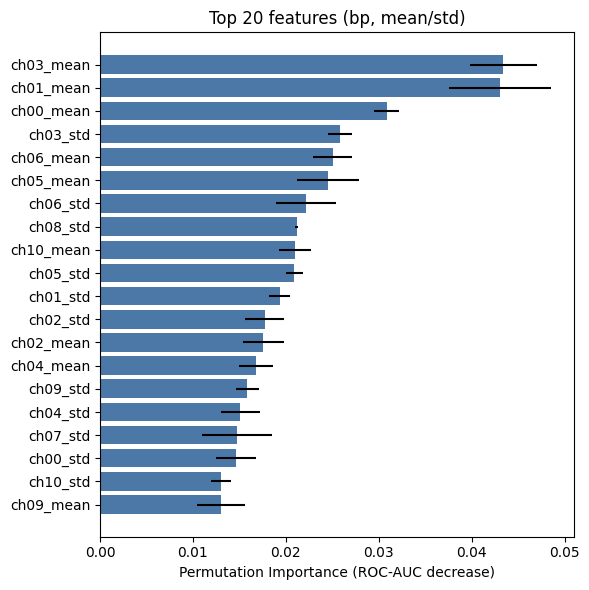

In [15]:
# after perm_df is created
perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)
top = perm_df.head(20).iloc[::-1]
plt.figure(figsize=(6, 6))
plt.barh(
    top["feature"], top["importance_mean"], xerr=top["importance_std"], color="#4C78A8"
)
plt.xlabel("Permutation Importance (ROC-AUC decrease)")
plt.title(f"Top 20 features ({IMP_PREPROC}, mean/std)")
plt.tight_layout()
plt.show()


In [16]:
# Run importance separately to avoid long output during training
# Choose preproc already trained (bp | bp_sc | bp_sc_norm)
IMP_PREPROC = "bp_sc"

pipe = locals()[f"pipe_{IMP_PREPROC}"]
feature_cols = locals()[f"cols_{IMP_PREPROC}"]
X_test = locals()[f"X_test_{IMP_PREPROC}"]
y_test_local = locals()[f"y_test_{IMP_PREPROC}"]

# s_importances(pipe, feature_cols, X_test, y_test_local, title=f'Top 20 features ({IMP_PREPROC}, mean/std)', n_jobs=1)
perm = permutation_importance(
    pipe,
    X_test,
    y_test_local,
    n_repeats=3,
    random_state=SEED,
    n_jobs=1,  # <-- avoids memmap/tmp usage
    scoring="roc_auc",
    max_samples=0.5,  # optional
)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:    0.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:    0.3s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed: 

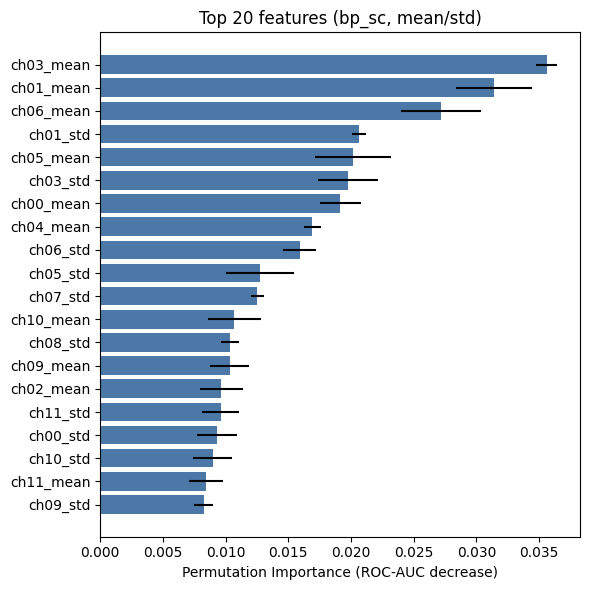

In [17]:
# after perm_df is created
perm_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)
top = perm_df.head(20).iloc[::-1]
plt.figure(figsize=(6, 6))
plt.barh(
    top["feature"], top["importance_mean"], xerr=top["importance_std"], color="#4C78A8"
)
plt.xlabel("Permutation Importance (ROC-AUC decrease)")
plt.title(f"Top 20 features ({IMP_PREPROC}, mean/std)")
plt.tight_layout()
plt.show()


In [18]:
# Run importance separately to avoid long output during training
# Choose preproc already trained (bp | bp_sc | bp_sc_norm)
IMP_PREPROC = "bp_sc_norm"

pipe = locals()[f"pipe_{IMP_PREPROC}"]
feature_cols = locals()[f"cols_{IMP_PREPROC}"]
X_test = locals()[f"X_test_{IMP_PREPROC}"]
y_test_local = locals()[f"y_test_{IMP_PREPROC}"]

# s_importances(pipe, feature_cols, X_test, y_test_local, title=f'Top 20 features ({IMP_PREPROC}, mean/std)', n_jobs=1)
perm = permutation_importance(
    pipe,
    X_test,
    y_test_local,
    n_repeats=3,
    random_state=SEED,
    n_jobs=1,  # <-- avoids memmap/tmp usage
    scoring="roc_auc",
    max_samples=0.5,  # optional
)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:    0.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:    0.4s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed: 

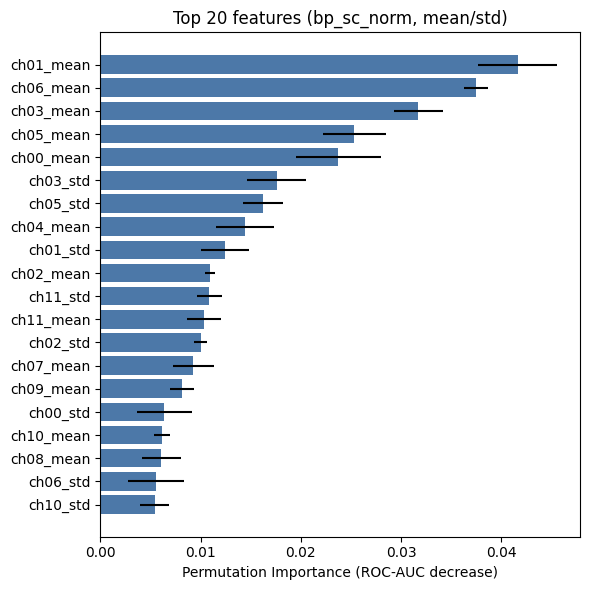

In [19]:
# after perm_df is created
perm_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)
top = perm_df.head(20).iloc[::-1]
plt.figure(figsize=(6, 6))
plt.barh(
    top["feature"], top["importance_mean"], xerr=top["importance_std"], color="#4C78A8"
)
plt.xlabel("Permutation Importance (ROC-AUC decrease)")
plt.title(f"Top 20 features ({IMP_PREPROC}, mean/std)")
plt.tight_layout()
plt.show()
